In [1]:

import os
import random
import numpy as np

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.environ["TF_DETERMINISTIC_OPS"] = "1"

In [2]:
df = pd.read_csv("thanjavur.csv")   
df = df.sort_values("time")

df["time"] = pd.to_datetime(df["time"])


feature_cols = [
    "temperature",
    "dewpoint",
    "pressure",
    "wind_u",
    "wind_v",
    "cloud_cover",
    "humidity"
]

target_col = "rain_mm"

In [3]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(df[feature_cols])
y_scaled = target_scaler.fit_transform(df[[target_col]])

In [4]:
sequence_length = 12   # 12 timesteps (72 hours)

def create_sequences(X, y, seq_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, sequence_length)


In [5]:
split_index = int(len(X_seq) * 0.8)

X_train, X_test = X_seq[:split_index], X_seq[split_index:]
y_train, y_test = y_seq[:split_index], y_seq[split_index:]

In [6]:
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(sequence_length, X_train.shape[2])),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()


/home/kc/py312/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 12, 64)         │        14,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,969 (93.63 KB)

 Trainable params: 23,969 (93.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.0086 - mae: 0.4028 - val_loss: 0.8136 - val_mae: 0.2962
Epoch 2/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.9822 - mae: 0.3857 - val_loss: 0.8110 - val_mae: 0.2945
Epoch 3/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9529 - mae: 0.3787 - val_loss: 0.8185 - val_mae: 0.3179
Epoch 4/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9403 - mae: 0.3773 - val_loss: 0.8097 - val_mae: 0.2971
Epoch 5/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.9362 - mae: 0.3701 - val_loss: 0.8155 - val_mae: 0.3109
Epoch 6/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9280 - mae: 0.3676 - val_loss: 0.8131 - val_mae: 0.3084
Epoch 7/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.9208 - mae: 0.3644 - val_loss: 0.8127 - val_mae: 0.3009
Epoch 8/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.9146 - mae: 0.3615 - val_loss: 0.8141 - val_mae: 0.3033
Epoch 9/30
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.914

In [8]:
y_pred_scaled = model.predict(X_test)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test)

# No negative rainfall
y_pred = np.clip(y_pred, 0, None)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [9]:
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    median_absolute_error
)

mse   = mean_squared_error(y_test_actual, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_actual, y_pred)
medae = median_absolute_error(y_test_actual, y_pred)
r2    = r2_score(y_test_actual, y_pred)

print("\nDetailed GRU Evaluation Metrics")
print("R²     :", round(r2, 4))
print("MSE    :", round(mse, 4))
print("RMSE   :", round(rmse, 4))
print("MAE    :", round(mae, 4))
print("MedAE  :", round(medae, 4))


Detailed GRU Evaluation Metrics
R²     : 0.043
MSE    : 0.1058
RMSE   : 0.3253
MAE    : 0.1069
MedAE  : 0.0324


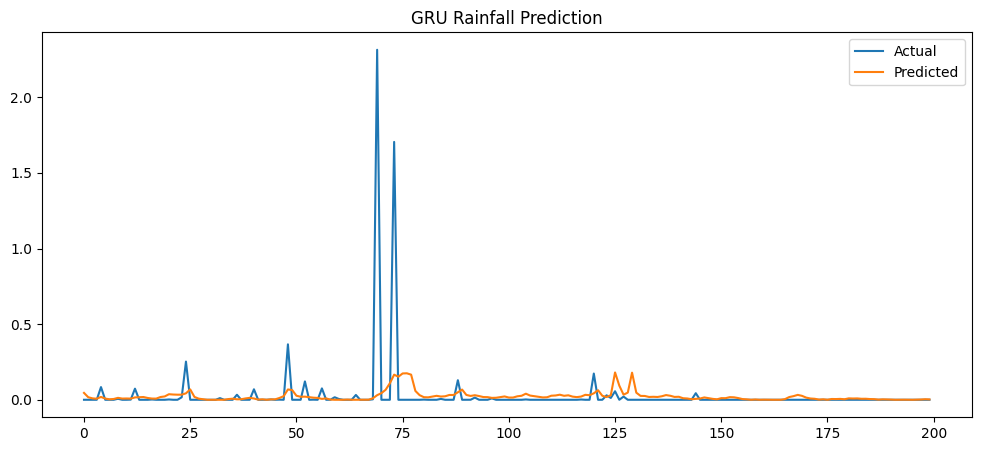

In [10]:
plt.figure(figsize=(12,5))
plt.plot(y_test_actual[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("GRU Rainfall Prediction")
plt.show()

In [11]:

latest_sequence_raw = df[feature_cols].tail(sequence_length)

latest_sequence_scaled = feature_scaler.transform(latest_sequence_raw)

latest_sequence_scaled = latest_sequence_scaled.reshape(1, sequence_length, len(feature_cols))

pred_scaled = model.predict(latest_sequence_scaled)

pred_real = target_scaler.inverse_transform(pred_scaled)

pred_real = np.clip(pred_real, 0, None)

print("\nPredicted Rainfall for Next Time Step:")
print(f"{pred_real[0][0]:.4f} mm")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step

Predicted Rainfall for Next Time Step:
0.0388 mm
